In [1]:
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

DATA_ROOT = Path.home() / "BLUEBERRY_DATA/MERGED"

IMAGES_DIR = DATA_ROOT / "images"
LABELS_DIR = DATA_ROOT / "labels"

# 0: bud, 1: flower, 2:green, 3:pink, 4:purple, 5:blue
CLASS_NAMES = ["bud", "flower", "green", "pink", "purple", "blue"]
NUM_CLASSES = len(CLASS_NAMES)

Counter({0: 468356, 2: 290420, 1: 268653, 5: 5654, 3: 4755, 4: 2296})


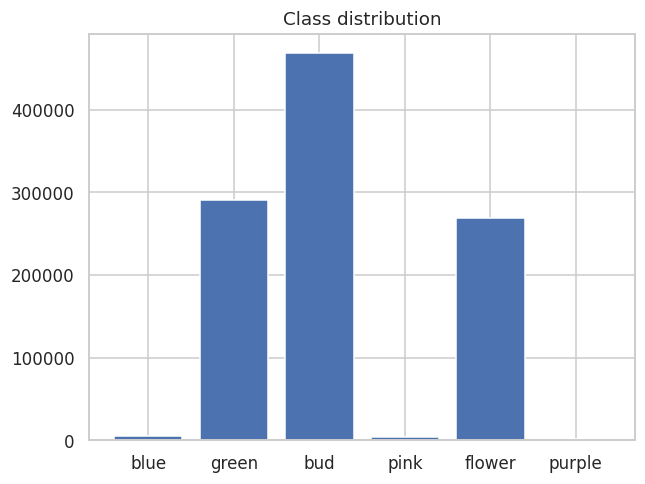

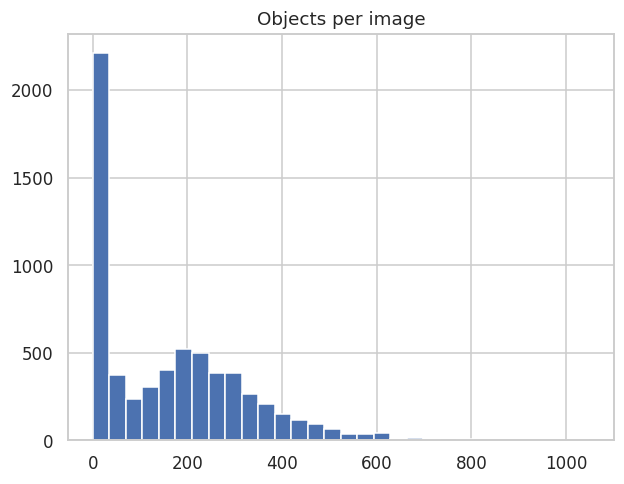

In [2]:
class_counts = Counter()
instances_per_image = []

# label_dir = "../data/labels/train"

# p = Path(label_dir)
for file in LABELS_DIR.iterdir():
  with file.open() as f:
    lines = f.readlines()
    instances_per_image.append(len(lines))
    for line in lines:
      cls = int(line.split()[0])
      class_counts[cls] += 1

print(class_counts)

# plot class imbalance
# plt.bar(class_counts.keys(), class_counts.values())
plt.bar(np.array(CLASS_NAMES)[list(class_counts.keys())], class_counts.values())
plt.title("Class distribution")
plt.show()

# Objects per image
plt.hist(instances_per_image, bins=30)
plt.title("Objects per image")
plt.show()

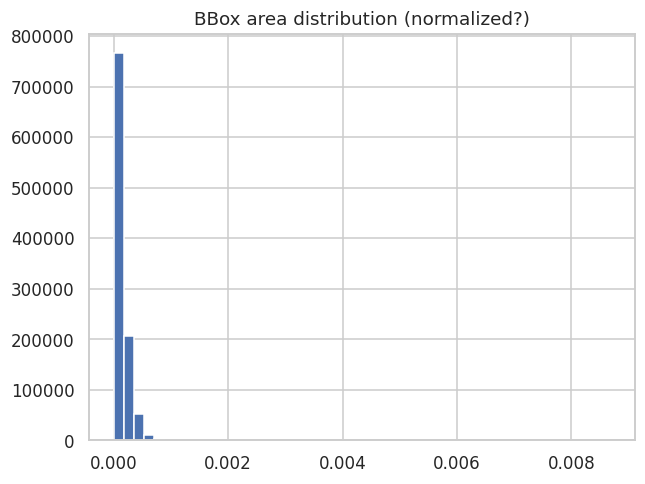

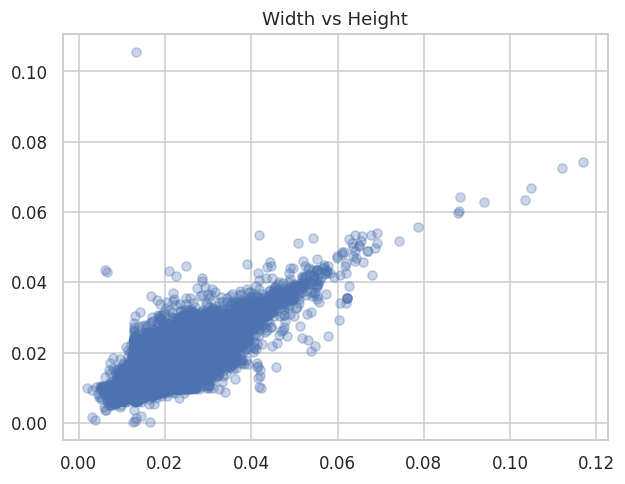

In [3]:
areas = []
widths = []
heights = []

for file in LABELS_DIR.iterdir():
  with file.open() as f:
    for line in f:
      _, _, _, w, h = map(float, line.split())
      widths.append(w)
      heights.append(h)
      areas.append(w*h)
      
plt.hist(areas, bins=50)
plt.title("BBox area distribution (normalized?)")
plt.show()

plt.scatter(widths, heights, alpha=0.3)
plt.title("Width vs Height")
plt.show()

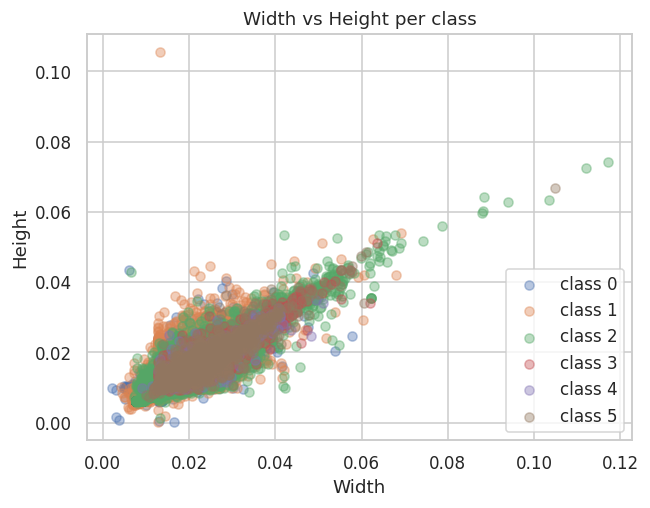

In [4]:
widths = []
heights = []
classes = []

for file in LABELS_DIR.iterdir():
  with file.open() as f:
    for line in f:
      cls, _, _, w, h = map(float, line.split())
      widths.append(w)
      heights.append(h)
      classes.append(int(cls))
      
# scatter = plt.scatter(widths, heights, c=classes, cmap="tab10", alpha=0.3)
# plt.colorbar(scatter, label="Class")
# plt.title("Width vs Height")
# plt.show()

classes_np = np.array(classes)
widths_np = np.array(widths)
heights_np = np.array(heights)

plt.figure()

for cls in np.unique(classes_np):
    mask = classes_np == cls
    plt.scatter(
        widths_np[mask],
        heights_np[mask],
        alpha=0.4,
        label=f"class {cls}"
    )

plt.legend()
plt.title("Width vs Height per class")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()

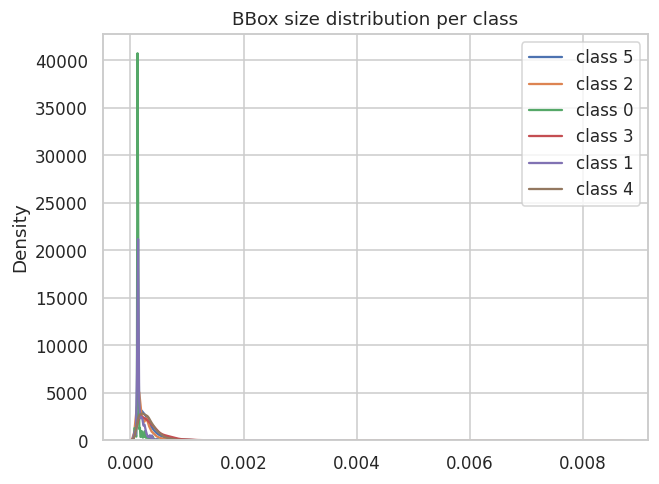

In [5]:
import seaborn as sns

class_areas = dict()

for file in LABELS_DIR.iterdir():
  with file.open() as f:
    for line in f:
      cls, _, _, w, h = map(float, line.split())
      class_areas.setdefault(int(cls), []).append(w*h)


for cls, vals in class_areas.items():
  sns.kdeplot(vals, label=f"class {cls}", multiple="layer")

plt.legend()
plt.title("BBox size distribution per class")
plt.show()